# TextAnalysis — Dos hipótesis, un corpus

**Pregunta:** ¿Hasta qué punto los partidos convergen en sus propuestas programáticas pese a mantener posiciones ideológicas diferenciadas?

- **H1:** los planes presentan un grado importante de similitud textual.
- **H2:** a pesar de esa convergencia, mantienen posiciones diferenciadas en una dimensión izquierda–derecha.

Usaremos **TF–IDF + similitud coseno** para H1 y **Wordscores** para H2.

## TEXT-01 — Leer el corpus preparado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ARCHIVO = Path("planes_gobierno_preparados.csv")
if not ARCHIVO.exists():
    raise FileNotFoundError("Ejecute primero preTextAnalysis.ipynb para crear planes_gobierno_preparados.csv")

df = pd.read_csv(ARCHIVO)
print("Documentos:", len(df))
df[["id_partido", "partido", "tipo_texto", "puntaje_referencia", "n_tokens"]]

Documentos: 8


,id_partido,partido,tipo_texto,puntaje_referencia,n_tokens
0,Partido_A,Renovación Popular Social,ancla,-1.0,64
1,Partido_B,Frente Progresista,virgin,NaN,61
2,Partido_C,Movimiento Democrático,virgin,NaN,60
3,Partido_D,Centro Cívico,virgin,NaN,60
4,Partido_E,Alianza Nacional,virgin,NaN,61
5,Partido_F,Libertad Republicana,virgin,NaN,59
6,Partido_G,Futuro Liberal,virgin,NaN,63
7,Partido_H,Mercado y Libertad,ancla,1.0,61


# Parte A — H1: Convergencia programática

## TEXT-02 — Construir la matriz documento–término

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer()
dtm = count_vec.fit_transform(df["texto_limpio"])
vocabulario = np.array(count_vec.get_feature_names_out())

print("Forma de la matriz:", dtm.shape)
print("Documentos:", dtm.shape[0])
print("Términos:", dtm.shape[1])

# Una muestra pequeña para ver la representación
muestra_terminos = vocabulario[:12]
muestra = pd.DataFrame(
    dtm[:, :12].toarray(),
    index=df["id_partido"],
    columns=muestra_terminos
)
muestra

Forma de la matriz: (8, 144)
Documentos: 8
Términos: 144


,accesibles,acceso,activo,administrativa,ambiental,apertura,asociaciones,calidad,capacitación,capaz,ciudadana,claras
id_partido,,,,,,,,,,,,
Partido_A,1,0,1,0,1,0,0,1,0,0,1,0
Partido_B,0,0,0,0,1,0,0,1,0,1,1,0
Partido_C,0,1,0,0,1,0,0,2,0,0,1,0
Partido_D,0,1,0,0,1,0,0,1,1,0,1,1
Partido_E,0,1,0,1,1,0,0,1,1,0,1,1
Partido_F,0,1,0,0,0,0,1,1,1,0,1,0
Partido_G,0,1,0,0,0,1,1,1,0,0,1,0
Partido_H,0,1,0,0,0,1,0,1,0,0,1,0


## TEXT-03 — Ponderar con TF–IDF

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
matriz_tfidf = tfidf_vec.fit_transform(df["texto_limpio"])
terminos = np.array(tfidf_vec.get_feature_names_out())

print("Top 5 términos TF–IDF por documento")
for i, partido in enumerate(df["id_partido"]):
    fila = matriz_tfidf[i].toarray().ravel()
    top = fila.argsort()[-5:][::-1]
    palabras = ", ".join(f"{terminos[j]} ({fila[j]:.2f})" for j in top)
    print(f"{partido}: {palabras}")

Top 5 términos TF–IDF por documento
Partido_A: derechos (0.28), pública (0.25), trabajadores (0.17), fortalezca (0.17), colectiva (0.17)
Partido_B: social (0.40), pública (0.27), combinar (0.18), responsable (0.18), programas (0.18)
Partido_C: sector (0.20), desigualdades (0.20), elevar (0.20), deben (0.20), gradual (0.20)
Partido_D: provee (0.22), oportunidades (0.22), regula (0.22), sostenible (0.18), mientras (0.18)
Partido_E: simplificación (0.21), garantiza (0.21), focalizada (0.21), administrativa (0.21), generar (0.21)
Partido_F: principal (0.22), motor (0.22), predecible (0.22), trabas (0.19), privadas (0.19)
Partido_G: estables (0.20), eliminación (0.20), creación (0.20), pero (0.20), trabas (0.17)
Partido_H: privada (0.23), fuerte (0.19), competitiva (0.19), desregulación (0.19), mercado (0.19)


## TEXT-04 — Calcular similitud coseno

id_partido,Partido_A,Partido_B,Partido_C,Partido_D,Partido_E,Partido_F,Partido_G,Partido_H
id_partido,,,,,,,,
Partido_A,1.000,0.484,0.341,0.246,0.253,0.228,0.186,0.224
Partido_B,0.484,1.000,0.403,0.340,0.373,0.307,0.244,0.231
Partido_C,0.341,0.403,1.000,0.437,0.368,0.382,0.307,0.270
Partido_D,0.246,0.340,0.437,1.000,0.705,0.520,0.383,0.324
Partido_E,0.253,0.373,0.368,0.705,1.000,0.560,0.420,0.339
Partido_F,0.228,0.307,0.382,0.520,0.560,1.000,0.630,0.418
Partido_G,0.186,0.244,0.307,0.383,0.420,0.630,1.000,0.618
Partido_H,0.224,0.231,0.270,0.324,0.339,0.418,0.618,1.000


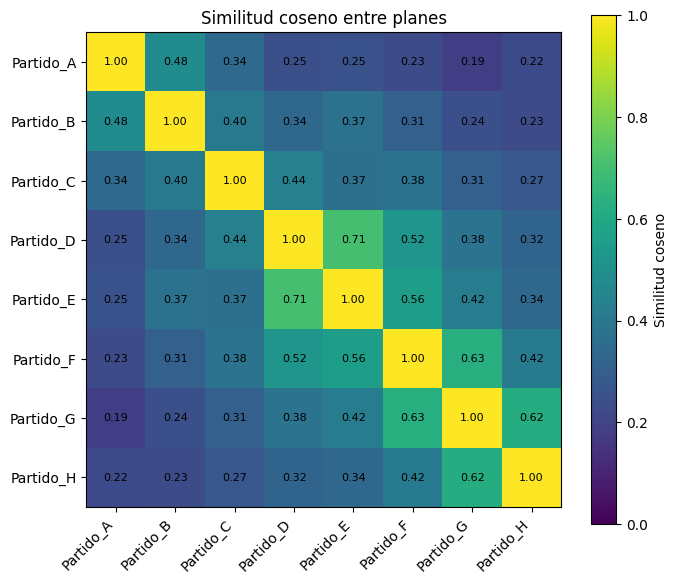

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

S = cosine_similarity(matriz_tfidf)
sim_df = pd.DataFrame(S, index=df["id_partido"], columns=df["id_partido"])

display(sim_df.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S, vmin=0, vmax=1)
ax.set_xticks(range(len(df)), labels=df["id_partido"], rotation=45, ha="right")
ax.set_yticks(range(len(df)), labels=df["id_partido"])
ax.set_title("Similitud coseno entre planes")
for i in range(len(df)):
    for j in range(len(df)):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Similitud coseno")
fig.tight_layout()
plt.show()

## TEXT-05 — Evaluar H1

In [5]:
# Criterio pedagógico fijado antes de interpretar el resultado
UMBRAL_H1 = 0.30

mascara = ~np.eye(len(df), dtype=bool)
similitudes_pares = S[mascara]
similitud_media = similitudes_pares.mean()

print(f"Similitud media entre pares: {similitud_media:.3f}")
print(f"Criterio pedagógico H1: >= {UMBRAL_H1:.2f}")
print("Evidencia compatible con H1:", bool(similitud_media >= UMBRAL_H1))

Similitud media entre pares: 0.376
Criterio pedagógico H1: >= 0.30
Evidencia compatible con H1: True


El umbral `0.30` **no es una regla universal**. En este ejercicio obliga a explicitar un criterio antes de mirar el resultado. Una tesis real debería justificar su referencia sustantiva o comparativa.

# Parte B — H2: Diferenciación ideológica

## TEXT-06 — Identificar los textos de referencia

In [6]:
referencias = df[df["tipo_texto"].eq("ancla")][
    ["id_partido", "partido", "puntaje_referencia"]
]
virgenes = df[df["tipo_texto"].eq("virgin")][["id_partido", "partido"]]

print("TEXTOS DE REFERENCIA")
display(referencias)
print("TEXTOS VÍRGENES")
display(virgenes)

TEXTOS DE REFERENCIA


,id_partido,partido,puntaje_referencia
0,Partido_A,Renovación Popular Social,-1.0
7,Partido_H,Mercado y Libertad,1.0


TEXTOS VÍRGENES


,id_partido,partido
1,Partido_B,Frente Progresista
2,Partido_C,Movimiento Democrático
3,Partido_D,Centro Cívico
4,Partido_E,Alianza Nacional
5,Partido_F,Libertad Republicana
6,Partido_G,Futuro Liberal


La dimensión izquierda–derecha no aparece automáticamente en los datos. Obtiene significado de los textos que fijamos como referencias y de los puntajes que les asignamos.

## TEXT-07 — Estimar puntajes de palabras

In [7]:
# Wordscores usa frecuencias de palabras, no TF-IDF
count_ws = CountVectorizer()
D = count_ws.fit_transform(df["texto_limpio"]).toarray()
vocab_ws = np.array(count_ws.get_feature_names_out())

# Frecuencia relativa de cada palabra dentro de cada documento
F = D / D.sum(axis=1, keepdims=True)

ref_idx = np.where(df["tipo_texto"].eq("ancla"))[0]
A = df.loc[ref_idx, "puntaje_referencia"].to_numpy(dtype=float)
F_ref = F[ref_idx, :]

# P(r|w): entre los textos de referencia, ¿dónde aparece relativamente más la palabra?
den = F_ref.sum(axis=0)
P_r_w = np.divide(F_ref, den, out=np.zeros_like(F_ref), where=den != 0)

# Puntaje de cada palabra
word_scores = (P_r_w * A[:, None]).sum(axis=0)

ws_palabras = pd.DataFrame({"palabra": vocab_ws, "wordscore": word_scores})
print("Palabras próximas al extremo izquierdo")
display(ws_palabras.sort_values("wordscore").head(10))
print("Palabras próximas al extremo derecho")
display(ws_palabras.sort_values("wordscore", ascending=False).head(10))

Palabras próximas al extremo izquierdo


,palabra,wordscore
0,accesibles,-1.0
2,activo,-1.0
4,ambiental,-1.0
12,colectiva,-1.0
29,derechos,-1.0
21,contribuir,-1.0
36,digno,-1.0
32,desigualdad,-1.0
54,estratégicas,-1.0
58,fortalezca,-1.0


Palabras próximas al extremo derecho


,palabra,wordscore
1,acceso,1.0
5,apertura,1.0
15,competencia,1.0
14,comercial,1.0
59,fuerte,1.0
75,libertad,1.0
77,liderar,1.0
65,impuestos,1.0
78,limitado,1.0
35,digitalización,1.0


## TEXT-08 — Proyectar los textos vírgenes

In [8]:
# Puntaje documental bruto
raw_scores = (F * word_scores).sum(axis=1)

# Reescalamiento lineal para conservar los anclajes -1 y +1 en este ejercicio
left_i, right_i = ref_idx[np.argsort(A)]
raw_left = raw_scores[left_i]
raw_right = raw_scores[right_i]

scaled = -1 + 2 * (raw_scores - raw_left) / (raw_right - raw_left)
df["wordscore"] = scaled

resultado_ws = df[["id_partido", "partido", "tipo_texto", "wordscore"]].copy()
resultado_ws["wordscore"] = resultado_ws["wordscore"].round(3)
resultado_ws

,id_partido,partido,tipo_texto,wordscore
0,Partido_A,Renovación Popular Social,ancla,-1.000
1,Partido_B,Frente Progresista,virgin,-0.418
2,Partido_C,Movimiento Democrático,virgin,-0.118
3,Partido_D,Centro Cívico,virgin,0.148
4,Partido_E,Alianza Nacional,virgin,0.147
5,Partido_F,Libertad Republicana,virgin,0.323
6,Partido_G,Futuro Liberal,virgin,0.648
7,Partido_H,Mercado y Libertad,ancla,1.000


## TEXT-09 — Evaluar H2

Rango entre textos vírgenes: 1.065
Criterio pedagógico H2: >= 0.75
Evidencia compatible con H2: True


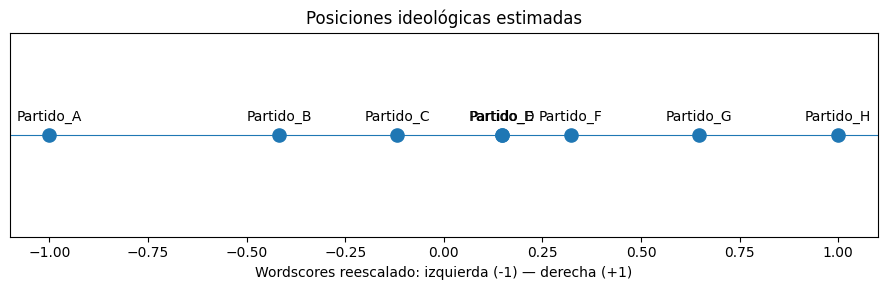

In [9]:
UMBRAL_H2 = 0.75

ws_virgenes = df.loc[df["tipo_texto"].eq("virgin"), "wordscore"]
rango_virgenes = ws_virgenes.max() - ws_virgenes.min()

print(f"Rango entre textos vírgenes: {rango_virgenes:.3f}")
print(f"Criterio pedagógico H2: >= {UMBRAL_H2:.2f}")
print("Evidencia compatible con H2:", bool(rango_virgenes >= UMBRAL_H2))

fig, ax = plt.subplots(figsize=(9, 3))
y = np.zeros(len(df))
ax.scatter(df["wordscore"], y, s=90)
ax.axhline(0, linewidth=0.8)
for _, row in df.iterrows():
    ax.annotate(row["id_partido"], (row["wordscore"], 0), xytext=(0, 10),
                textcoords="offset points", ha="center")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-0.15, 0.15)
ax.set_yticks([])
ax.set_xlabel("Wordscores reescalado: izquierda (-1) — derecha (+1)")
ax.set_title("Posiciones ideológicas estimadas")
fig.tight_layout()
plt.show()

Como en H1, `0.75` es un criterio pedagógico del ejercicio, no una regla universal de Wordscores.

## TEXT-10 — Reconstruir la evidencia

In [10]:
print("H1 — CONVERGENCIA PROGRAMÁTICA")
print(f"Similitud coseno media = {similitud_media:.3f} | criterio = {UMBRAL_H1:.2f}")
print(f"Compatible con H1: {similitud_media >= UMBRAL_H1}")

print("\nH2 — DIFERENCIACIÓN IDEOLÓGICA")
print(f"Rango Wordscores entre textos vírgenes = {rango_virgenes:.3f} | criterio = {UMBRAL_H2:.2f}")
print(f"Compatible con H2: {rango_virgenes >= UMBRAL_H2}")

print("\nPosiciones estimadas:")
display(resultado_ws)

H1 — CONVERGENCIA PROGRAMÁTICA
Similitud coseno media = 0.376 | criterio = 0.30
Compatible con H1: True

H2 — DIFERENCIACIÓN IDEOLÓGICA
Rango Wordscores entre textos vírgenes = 1.065 | criterio = 0.75
Compatible con H2: True

Posiciones estimadas:


,id_partido,partido,tipo_texto,wordscore
0,Partido_A,Renovación Popular Social,ancla,-1.000
1,Partido_B,Frente Progresista,virgin,-0.418
2,Partido_C,Movimiento Democrático,virgin,-0.118
3,Partido_D,Centro Cívico,virgin,0.148
4,Partido_E,Alianza Nacional,virgin,0.147
5,Partido_F,Libertad Republicana,virgin,0.323
6,Partido_G,Futuro Liberal,virgin,0.648
7,Partido_H,Mercado y Libertad,ancla,1.000


## Lectura final

El mismo corpus puede ser compatible simultáneamente con **convergencia programática** y **diferenciación ideológica** porque TF–IDF/coseno y Wordscores responden preguntas distintas.

La secuencia de investigación es:

**pregunta → hipótesis → evidencia necesaria → organización del corpus → representación → técnica → interpretación**.